In [3]:
import pandas as pd #for data handling
import numpy as np #for numerical calculation
import matplotlib.pyplot as plt #for data visualization
import seaborn as sns 

from sklearn.model_selection import train_test_split #for splitting dataset into training and testing 
from sklearn.preprocessing import LabelEncoder #to convert text values into numbers 
from sklearn.ensemble import RandomForestRegressor #ML algorithm 

#evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
df= pd.read_csv(r"C:\Users\sohai\Downloads\car data.csv") #read csv file 
print("First 5 rows ") #display first 5 rows
print(df.head())

First 5 rows 
  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [7]:
#display dataset information 
print("Dataset information :")
print(df.info())

Dataset information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None


In [9]:
#display statistical summary 
print("Statistical summary :")
print(df.describe())
      

Statistical summary :
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%    2012.000000       0.900000       1.200000   15000.000000    0.000000
50%    2014.000000       3.600000       6.400000   32000.000000    0.000000
75%    2016.000000       6.000000       9.900000   48767.000000    0.000000
max    2018.000000      35.000000      92.600000  500000.000000    3.000000


In [10]:
#check for any missing values 
print("Missing values:")
print(df.isnull().sum())

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


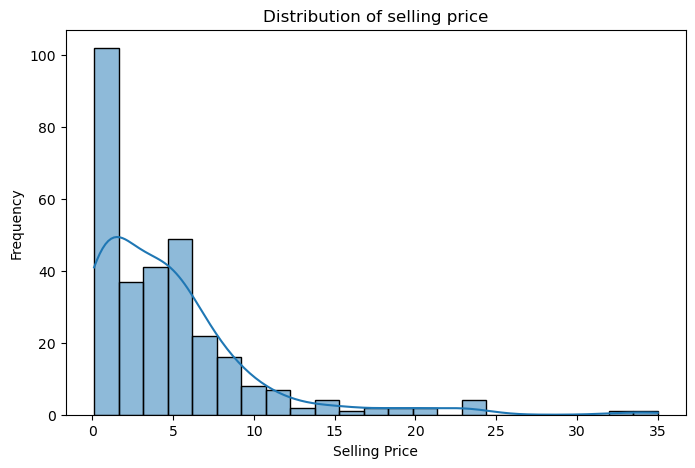

In [12]:
#perform EDA 
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"],kde=True )
plt.title("Distribution of selling price")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

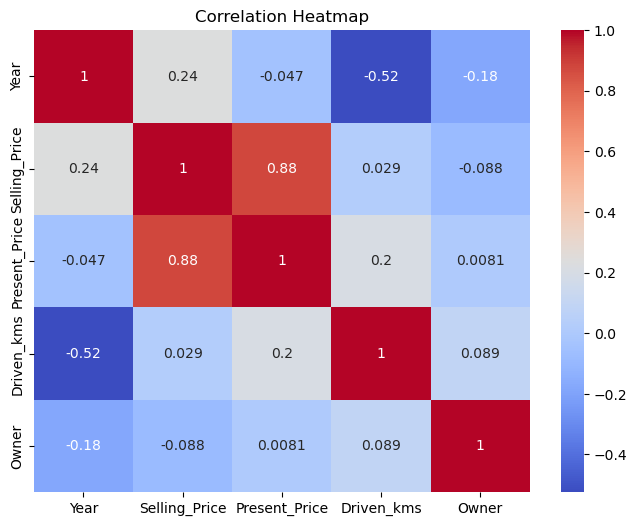

In [13]:
#correlation heatmap 
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))

sns.heatmap( numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [14]:
#performingf feature engineering
current_year = 2026

df["Car_Age"] = current_year - df["Year"]
df.drop("Year", axis=1, inplace=True)

print("\nDataset after adding Car_Age:")
print(df.head())


Dataset after adding Car_Age:
  Car_Name  Selling_Price  Present_Price  Driven_kms Fuel_Type Selling_type  \
0     ritz           3.35           5.59       27000    Petrol       Dealer   
1      sx4           4.75           9.54       43000    Diesel       Dealer   
2     ciaz           7.25           9.85        6900    Petrol       Dealer   
3  wagon r           2.85           4.15        5200    Petrol       Dealer   
4    swift           4.60           6.87       42450    Diesel       Dealer   

  Transmission  Owner  Car_Age  
0       Manual      0       12  
1       Manual      0       13  
2       Manual      0        9  
3       Manual      0       15  
4       Manual      0       12  


In [15]:
#Encoding categorical data 
encoder = LabelEncoder()

df["Fuel_Type"] = encoder.fit_transform(df["Fuel_Type"])
df["Selling_type"] = encoder.fit_transform(df["Selling_type"])
df["Transmission"] = encoder.fit_transform(df["Transmission"])
df["Car_Name"] = encoder.fit_transform(df["Car_Name"])

print("\nEncoded Dataset:")
print(df.head())


Encoded Dataset:
   Car_Name  Selling_Price  Present_Price  Driven_kms  Fuel_Type  \
0        90           3.35           5.59       27000          2   
1        93           4.75           9.54       43000          1   
2        68           7.25           9.85        6900          2   
3        96           2.85           4.15        5200          2   
4        92           4.60           6.87       42450          1   

   Selling_type  Transmission  Owner  Car_Age  
0             0             1      0       12  
1             0             1      0       13  
2             0             1      0        9  
3             0             1      0       15  
4             0             1      0       12  


In [16]:
#defining features and target variable
y = df["Selling_Price"]
X = df.drop("Selling_Price", axis=1)

print("Features:")
print(X.columns)

Features:
Index(['Car_Name', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type',
       'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


In [17]:
#splitting dataset for training and testing 
X_train, X_test, y_train, y_test = train_test_split( X,  y, test_size=0.20, random_state=42 )
# 80% for trainng and 20% for testing 

print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



Training Data Shape: (240, 8)
Testing Data Shape: (61, 8)


In [18]:
#training ML model 
model = RandomForestRegressor( n_estimators=100,  random_state=42 )
model.fit(X_train, y_train)

print("Model Training Completed Successfully")

Model Training Completed Successfully


In [19]:
#make predictions
y_pred = model.predict(X_test)

print("\nFirst 10 Predictions:")
print(y_pred[:10])




First 10 Predictions:
[ 0.4443 10.3488  4.972   0.2159  7.9384  6.698   1.134   0.606   0.4667
  6.602 ]


In [20]:
#model evalution 
mae = mean_absolute_error(y_test, y_pred) #mean absolute error
mse = mean_squared_error(y_test, y_pred) #mean square error 
r2 = r2_score(y_test, y_pred) #r2 score 

print("Model Evaluation")
print("-----------------------")
print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

Model Evaluation
-----------------------
MAE: 0.6021950819672133
MSE: 0.7969036719672131
R² Score: 0.9654055371911539


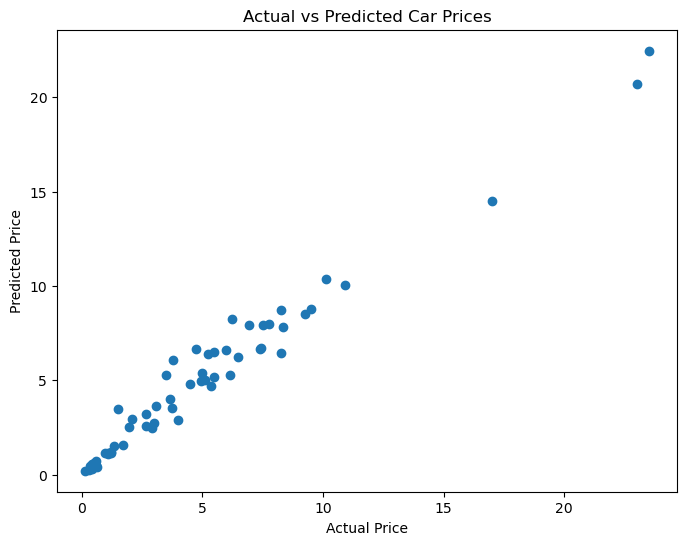

In [21]:
# actual vs  predicted graph 
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.show()


Feature Importance:
         Feature  Importance
1  Present_Price    0.869197
7        Car_Age    0.053791
2     Driven_kms    0.036299
0       Car_Name    0.029633
5   Transmission    0.007477
4   Selling_type    0.002178
3      Fuel_Type    0.001365
6          Owner    0.000061


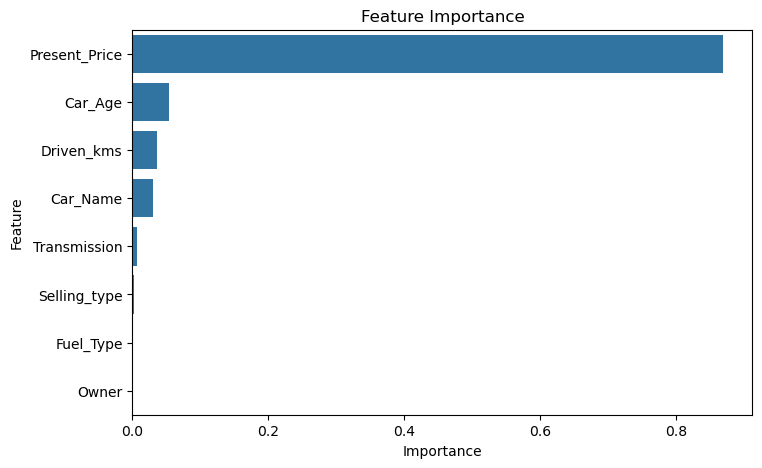

In [22]:
#showing which influence car price the most 
#Feature Importance 
importance = model.feature_importances_
feature_importance = pd.DataFrame({ 'Feature': X.columns, 'Importance': importance})
feature_importance = feature_importance.sort_values( by='Importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)
plt.figure(figsize=(8,5))

sns.barplot( x='Importance', y='Feature', data=feature_importance)
plt.title("Feature Importance")
plt.show()

In [23]:
#sample prediction 
sample_car = pd.DataFrame({ 'Car_Name': [0], 'Present_Price': [5.59], 'Driven_kms': [27000], 'Fuel_Type': [2],'Selling_type': [0],'Transmission': [1], 'Owner': [0],'Car_Age': [7]})
predicted_price = model.predict(sample_car)

print("Predicted Selling Price:")
print(predicted_price[0])

Predicted Selling Price:
4.123000000000002
